In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('/kaggle/input/datasets/peyonasayson/cleanedwithoutrating/CLEANED(without Rating)_dataset.csv')

print("Dataset loaded")
print(f"Shape: {df.shape}")
print(df['Label'].value_counts())

Dataset loaded
Shape: (40411, 3)
Label
OR    20215
CG    20196
Name: count, dtype: int64


In [11]:
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"GPU: {gpus[0]}")

GPU Available: True
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [12]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Character set (lowercase only for clean dataset)
charset = "abcdefghijklmnopqrstuvwxyz0123456789 .,!?"
char_to_idx = {ch: i+1 for i, ch in enumerate(charset)}
char_to_idx['<PAD>'] = 0
vocab_size = len(char_to_idx)
MAX_LEN = 300

def text_to_indices(text):
    text = str(text).lower()
    indices = [char_to_idx.get(ch, 0) for ch in text[:MAX_LEN]]
    if len(indices) < MAX_LEN:
        indices = indices + [0] * (MAX_LEN - len(indices))
    return indices[:MAX_LEN]

# Features (review only, no rating)
X = np.array([text_to_indices(review) for review in df['Review']])

# Target: OR = 1, CG = 0
y = (df['Label'] == 'OR').astype(int)

print(f"X shape: {X.shape}")
print(f"Class distribution: CG={sum(y==0)}, OR={sum(y==1)}")

# Split 80/10/10
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

X shape: (40411, 300)
Class distribution: CG=20196, OR=20215
Train: 32328, Val: 4041, Test: 4042


In [15]:
from tensorflow.keras import regularizers

def create_model():
     inputs = layers.Input(shape=(MAX_LEN,))
     x = layers.Embedding(vocab_size, 64)(inputs)
    
     x = layers.Conv1D(64, kernel_size=5, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
     x = layers.MaxPooling1D(2)(x)
     x = layers.Conv1D(64, kernel_size=5, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
     x = layers.GlobalMaxPooling1D()(x)
     x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
     x = layers.Dropout(0.5)(x)
     outputs = layers.Dense(2, activation='softmax')(x)
    
     model = models.Model(inputs=inputs, outputs=outputs)
     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
     return model

print("Model ready")

Model ready


TRAINING 20 EPOCHS (WITHOUT RATING)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 300, 64)        │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 296, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 148, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 144, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,922 (179.38 KB)

 Trainable params: 45,922 (179.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6351 - loss: 0.6212 - val_accuracy: 0.8735 - val_loss: 0.3247
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8670 - loss: 0.3478 - val_accuracy: 0.8943 - val_loss: 0.2717
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8972 - loss: 0.2871 - val_accuracy: 0.8906 - val_loss: 0.2783
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9094 - loss: 0.2547 - val_accuracy: 0.9079 - val_loss: 0.2481
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9217 - loss: 0.2317 - val_accuracy: 0.9099 - val_loss: 0.2389
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9229 - loss: 0.2191 - val_accuracy: 0.8847 - val_loss: 0.3095
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9340 - loss: 0.2023 - val_accuracy: 0.9082 - val_loss: 0.2552
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9423 - loss: 0.1817 - val_accuracy: 0

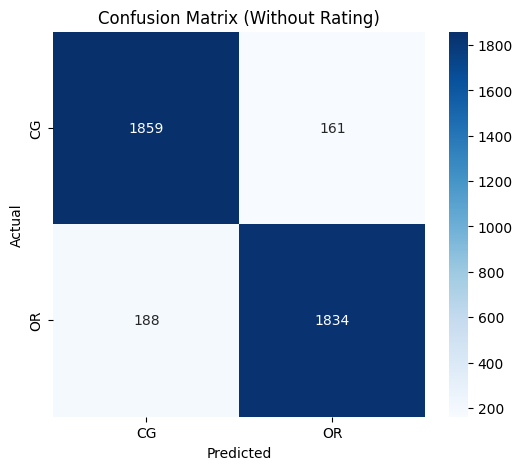

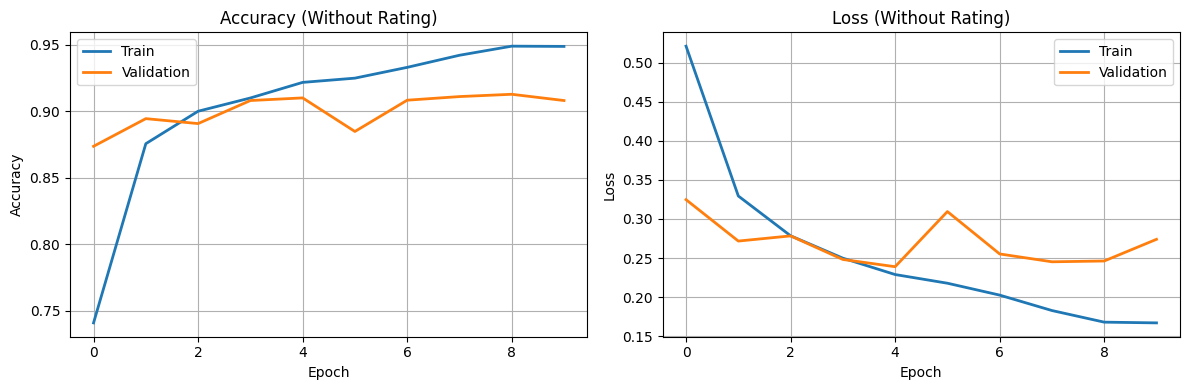

In [16]:
print("="*50)
print("TRAINING 20 EPOCHS (WITHOUT RATING)")
print("="*50)

model = create_model()
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['CG', 'OR']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['CG', 'OR'], yticklabels=['CG', 'OR'])
plt.title('Confusion Matrix (Without Rating)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Subplot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Accuracy (Without Rating)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Loss (Without Rating)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
print("="*50)
print("TEST YOUR OWN REVIEW")
print("CG = Computer Generated, OR = Original Review")
print("="*50)

def predict_review(review_text):
    indices = text_to_indices(review_text)
    review_input = np.array([indices])
    pred = model.predict(review_input, verbose=0)
    
    if pred[0][0] > pred[0][1]:
        print(f"Result: COMPUTER GENERATED (CG)")
        print(f"Confidence: {pred[0][0]:.4f}")
    else:
        print(f"Result: ORIGINAL (OR)")
        print(f"Confidence: {pred[0][1]:.4f}")

while True:
    user = input("\nReview (or 'exit'): ")
    if user.lower() == 'exit':
        break
    if user.strip():
        predict_review(user)

TEST YOUR OWN REVIEW
CG = Computer Generated, OR = Original Review



Review (or 'exit'):  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance.


Result: COMPUTER GENERATED (CG)
Confidence: 0.9557



Review (or 'exit'):  This item arrived in excellent condition, the packaging was secure and the delivery was good.


Result: ORIGINAL (OR)
Confidence: 0.6394


...


Review (or 'exit'):  So far so good, I had a bit of trouble setting it up at first but I figured it out after watching a video. 


Result: COMPUTER GENERATED (CG)
Confidence: 0.7255



Review (or 'exit'):  Honestly, it’s okay for the price I don't think it’s the best out there but it gets the job done for me.


Result: ORIGINAL (OR)
Confidence: 0.8172



Review (or 'exit'):  exit
